In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
X_train.shape

(50000, 32, 32, 3)

In [ ]:
X_test.shape

(10000, 32, 32, 3)

In [ ]:
X_train.shape

(50000, 32, 32, 3)

In [ ]:
y_train.shape

(50000, 1)

In [ ]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [ ]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [ ]:
y_test = y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [ ]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [ ]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

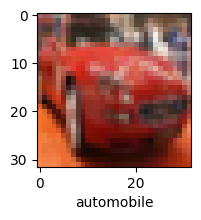

In [ ]:
plot_sample(X_train, y_train, 5)

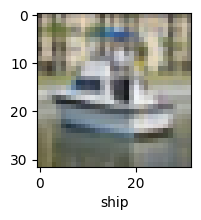

In [ ]:
plot_sample(X_train, y_train, 501)

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation = 'softmax')
])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 138s 87ms/step - accuracy: 0.3533 - loss: 1.8135
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 88ms/step - accuracy: 0.4264 - loss: 1.6256
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 88ms/step - accuracy: 0.4557 - loss: 1.5446
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 91ms/step - accuracy: 0.4779 - loss: 1.4855
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 156s 100ms/step - accuracy: 0.4978 - loss: 1.4330


In [ ]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print('classification report: \n',classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step
classification report: 
               precision    recall  f1-score   support

           0       0.68      0.29      0.40      1000
           1       0.54      0.70      0.61      1000
           2       0.43      0.26      0.32      1000
           3       0.37      0.24      0.29      1000
           4       0.54      0.28      0.37      1000
           5       0.43      0.35      0.39      1000
           6       0.42      0.71      0.52      1000
           7       0.55      0.55      0.55      1000
           8       0.41      0.80      0.54      1000
           9       0.50      0.51      0.51      1000

    accuracy                           0.47     10000
   macro avg       0.49      0.47      0.45     10000
weighted avg       0.49      0.47      0.45     10000



In [ ]:
import seaborn as sns

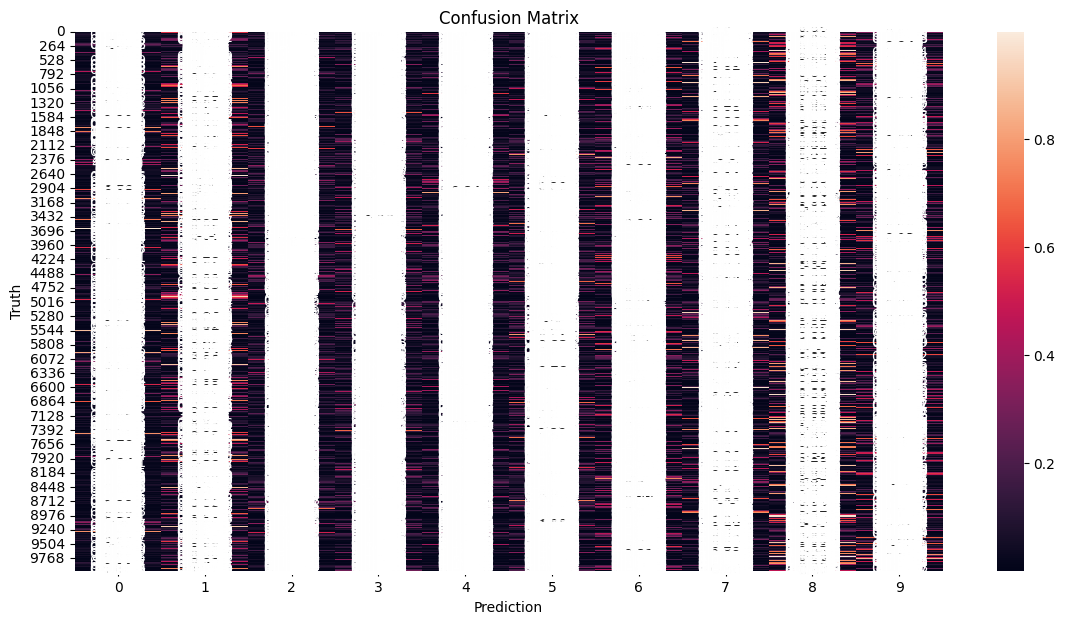

In [ ]:
plt.figure(figsize=(14,7))
sns.heatmap(y_pred, annot = True)
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
cnn = models.Sequential([
        layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(optimizer = 'adam',
            loss = 'sparse_categorical_crossentropy',
            metrics = ['accuracy'])

In [ ]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.4823 - loss: 1.4441
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6126 - loss: 1.1064
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.6554 - loss: 0.9898
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 40ms/step - accuracy: 0.6851 - loss: 0.9104
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.7076 - loss: 0.8445
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.7276 - loss: 0.7884
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.7405 - loss: 0.7428
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 39ms/step - accuracy: 0.7563 - loss: 0.7008
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.7695 - loss: 0.6613
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 39ms/step - accuracy: 0.7813 - loss: 0.6256


In [ ]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6989 - loss: 0.9210


[0.9209749102592468, 0.6988999843597412]

In [ ]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


array([[2.96049169e-03, 7.59551840e-05, 8.78679741e-04, 9.48474288e-01,
        7.43289420e-04, 3.06339767e-02, 1.27090290e-02, 6.80283483e-05,
        3.41752707e-03, 3.88390508e-05],
       [9.10143368e-03, 2.34122425e-01, 2.06693294e-04, 2.50658468e-05,
        1.63240781e-08, 1.22001973e-06, 1.04653843e-07, 3.34104516e-06,
        7.55359054e-01, 1.18061667e-03],
       [1.08104035e-01, 3.11878592e-01, 9.36736818e-04, 1.63951982e-02,
        2.36825086e-03, 1.44978403e-03, 3.53644864e-04, 9.37280804e-03,
        3.52156997e-01, 1.96983948e-01],
       [2.28205606e-01, 1.54636349e-04, 3.93085741e-03, 1.94797094e-03,
        1.43627939e-03, 9.31195027e-05, 2.83845060e-04, 6.05242531e-05,
        7.63857424e-01, 2.98161904e-05],
       [4.48762364e-07, 1.25304787e-05, 2.25158990e-03, 7.94999115e-03,
        2.56573081e-01, 5.80610195e-03, 7.27364421e-01, 5.06174047e-07,
        4.13436646e-05, 2.85777162e-08]], dtype=float32)

In [ ]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(8), np.int64(6)]

In [ ]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

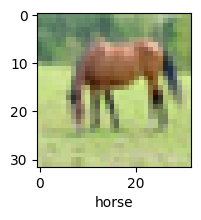

In [ ]:
plot_sample(X_test, y_test, 60)

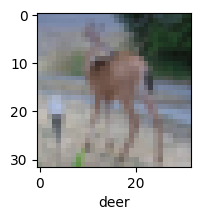

In [ ]:
plot_sample(X_test, y_test, 100)

In [ ]:
classes[y_classes[60]]

'horse'

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171,178 (8.28 MB)

 Trainable params: 2,169,770 (8.28 MB)

 Non-trainable params: 1,408 (5.50 KB)

Training Enhanced CNN...
Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 395s 250ms/step - accuracy: 0.4298 - loss: 1.6669 - val_accuracy: 0.4932 - val_loss: 1.4871
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 445s 252ms/step - accuracy: 0.5492 - loss: 1.2621 - val_accuracy: 0.5967 - val_loss: 1.2076
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 394s 252ms/step - accuracy: 0.5958 - loss: 1.1483 - val_accuracy: 0.6463 - val_loss: 1.0376
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 391s 250ms/step - accuracy: 0.6244 - loss: 1.0755 - val_accuracy: 0.6495 - val_loss: 1.0144
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 442s 251ms/step - accuracy: 0.6421 - loss: 1.0206 - val_accuracy: 0.5974 - val_loss: 1.3574
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 395s 253ms/step - accuracy: 0.6596 - loss: 0.9730 - val_accuracy: 0.6672 - val_loss: 0.9843
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 443s 253ms/step - accuracy: 0.6721 - loss: 0.9393 - val_accuracy: 0.7043 - val_loss: 0.8549
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━

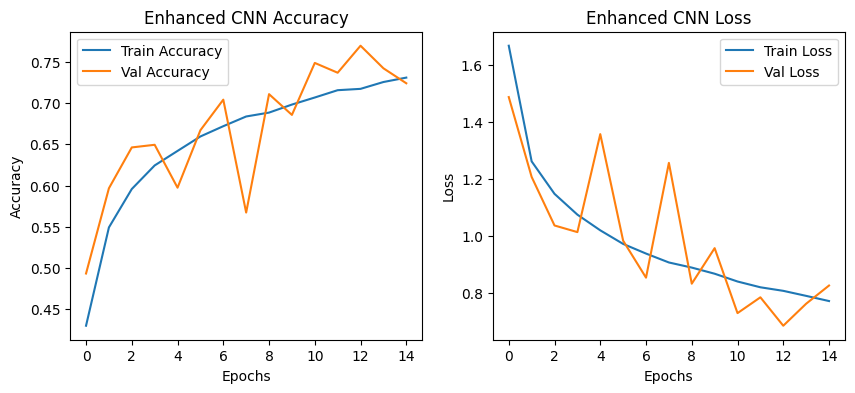

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Load and Preprocess Data
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

# Normalize pixel values to be between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

# 2. Define Data Augmentation Layer
data_augmentation = models.Sequential([
  layers.RandomFlip("horizontal", input_shape=(32, 32, 3)),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

# 3. Build the Enhanced CNN Architecture
enhanced_cnn = models.Sequential([
    # Apply Data Augmentation first
    data_augmentation,

    # Block 1: Deeper Convolutional Layers + Batch Normalization
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2: Extract higher-level features
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 3: Final Classification Layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# 4. Compile the Model using Adam Optimizer
enhanced_cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Print the architecture summary
enhanced_cnn.summary()

# 5. Train the Enhanced Model
print("Training Enhanced CNN...")
history_enhanced = enhanced_cnn.fit(X_train, y_train, epochs=15,
                                    validation_data=(X_test, y_test))

# 6. Evaluate and Compare
print("\nEvaluating Enhanced CNN on Test Data:")
test_loss, test_acc = enhanced_cnn.evaluate(X_test, y_test)
print(f"Enhanced CNN Test Accuracy: {test_acc*100:.2f}%")

# 7. Visualize the Training Progress
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_enhanced.history['accuracy'], label='Train Accuracy')
plt.plot(history_enhanced.history['val_accuracy'], label='Val Accuracy')
plt.title('Enhanced CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_enhanced.history['loss'], label='Train Loss')
plt.plot(history_enhanced.history['val_loss'], label='Val Loss')
plt.title('Enhanced CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

TypeError: only integer scalar arrays can be converted to a scalar index

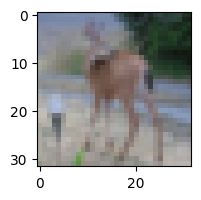

In [ ]:
plot_sample(X_test, y_test, 100)